<a href="https://colab.research.google.com/github/nekeitrius/Sales-Data-Analysis-Visualization-Project/blob/main/Ecommerce_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loading Data and Neccessary Packages**

In [ ]:
#Import needed packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set(color_codes=True)

In [ ]:
# load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/global_ecommerce_sales.csv')

# **Analysis of Data**

In [ ]:
#Check Duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head(5) #display first 5 rows

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


In [ ]:
df.tail(5) #display late 5 rows

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
1995,ORD-10823,2025-12-31,Linda Nilsson,Consumer,France,Europe,Furniture,Folding Table Portable,5,104.73,0,523.65,19.10,190.36,PayPal
1996,ORD-10896,2025-12-31,Ayumi Dubois,Consumer,France,Europe,Clothing & Accessories,Cotton Formal Shirt,11,59.27,5,619.37,20.94,272.44,PayPal
1997,ORD-11148,2025-12-31,Barbara Jones,Consumer,Spain,Europe,Technology,Webcam HD 1080p,6,31.79,15,162.13,15.19,42.03,Bank Transfer
1998,ORD-11519,2025-12-31,Maria Suzuki,Home Office,Spain,Europe,Clothing & Accessories,Sports Water Bottle 750ml,5,9.50,5,45.12,14.25,7.12,Credit Card
1999,ORD-11701,2025-12-31,Susan Russo,Home Office,South Korea,Asia Pacific,Clothing & Accessories,Sports Water Bottle 750ml,11,28.27,0,310.97,36.23,119.26,Credit Card


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   object 
 1   Order_Date        2000 non-null   object 
 2   Customer_Name     2000 non-null   object 
 3   Customer_Segment  2000 non-null   object 
 4   Country           2000 non-null   object 
 5   Region            2000 non-null   object 
 6   Product_Category  2000 non-null   object 
 7   Product_Name      2000 non-null   object 
 8   Quantity          2000 non-null   int64  
 9   Unit_Price        2000 non-null   float64
 10  Discount_Percent  2000 non-null   int64  
 11  Total_Sales       2000 non-null   float64
 12  Shipping_Cost     2000 non-null   float64
 13  Profit            2000 non-null   float64
 14  Payment_Method    2000 non-null   object 
dtypes: float64(4), int64(2), object(9)
memory usage: 234.5+ KB


,0
Order_ID,0
Order_Date,0
Customer_Name,0
Customer_Segment,0
Country,0
Region,0
Product_Category,0
Product_Name,0
Quantity,0
Unit_Price,0


In [ ]:
# Checking Balance of Dataset (Skewed or Not)
cols = ['Customer_Segment', 'Region', 'Product_Category', 'Payment_Method']

for col in cols:
    print(f"\n{col} Distribution (%):")
    print(df[col].value_counts(normalize=True) * 100)


Customer_Segment Distribution (%):
Customer_Segment
Consumer       50.30
Corporate      31.15
Home Office    18.55
Name: proportion, dtype: float64

Region Distribution (%):
Region
North America           28.90
Asia Pacific            26.00
Europe                  25.15
Middle East & Africa    10.40
South America            9.55
Name: proportion, dtype: float64

Product_Category Distribution (%):
Product_Category
Technology                28.35
Office Supplies           25.65
Furniture                 25.35
Clothing & Accessories    20.65
Name: proportion, dtype: float64

Payment_Method Distribution (%):
Payment_Method
Credit Card         39.85
PayPal              30.45
Cash on Delivery    15.05
Bank Transfer       14.65
Name: proportion, dtype: float64


**Customer Segement (Consumer, Corporate, Home Office)**

---

The dataset is moderately skewed toward consumer customers, though corporate and home office segments remain sufficiently represented for meaningful analysis.
*   Consumer: 50.3%
*   Corporate: 31.15%
*   Home Office: 18.55%



**Region(North American, Asia Pacific, Europe, Middle East & Africa, South America)**

---
Sales are concentrated in North America, Europe, and Asia Pacific, with relatively lower representation from emerging markets
*   North America: 28.9%
*   Asia Pacific: 26.0%
*   Europe: 25.15%
*   Middle East & Africa: 10.4%
*   South America: 9.55%


**Product Category**

---

Product categories are evenly distributed, enabling unbiased comparisons in sales and profitability across categories
*   Technology: 28.35%
*   Office Supplies: 25.65%
*   Furniture: 25.35%
*   Clothing: 20.65%


**Payment Method**

---
Customers show a strong preference for digital payment methods, particularly credit cards and PayPal
*   Credit Card: 39.85%
*   PayPal: 30.45%
*   Cash on Delivery: 15.05%
*   Bank Transfer: 14.65%



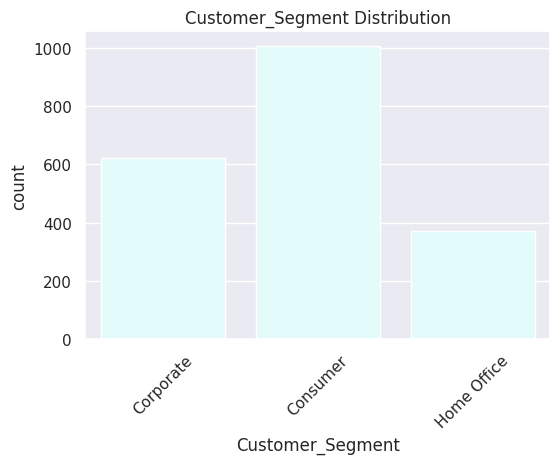

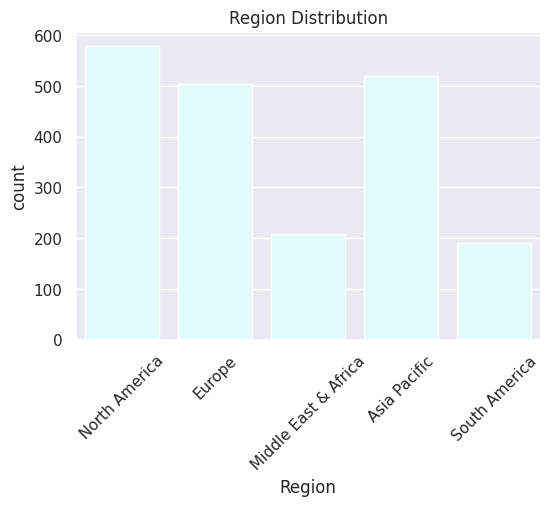

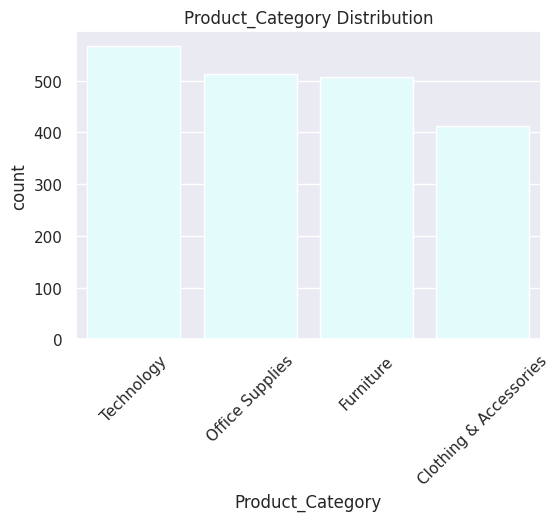

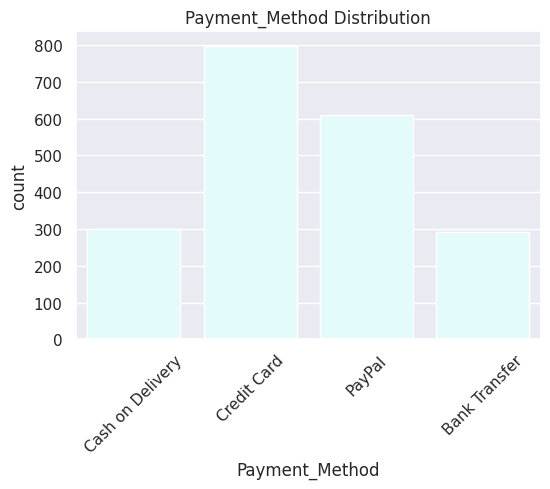

In [ ]:
for col in cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, color="lightcyan")
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
    plt.show()

# **Data Cleaning and Preparation**

In [ ]:
# Converting Date Column from Object(Text) to String (Actual Date #)
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [ ]:
# Breaking out Date column to Year, Month and Day of Week
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Day_of_Week'] = df['Order_Date'].dt.day_name()

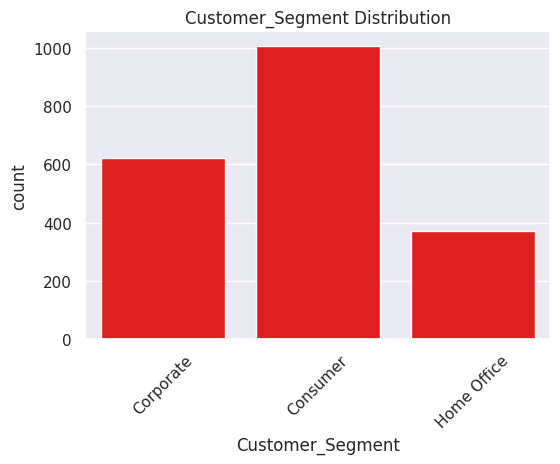

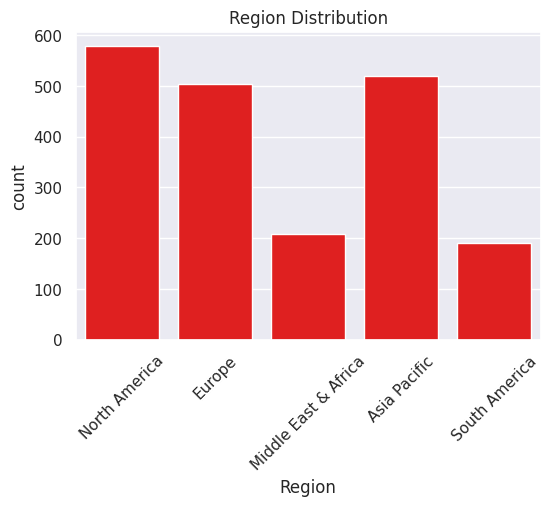

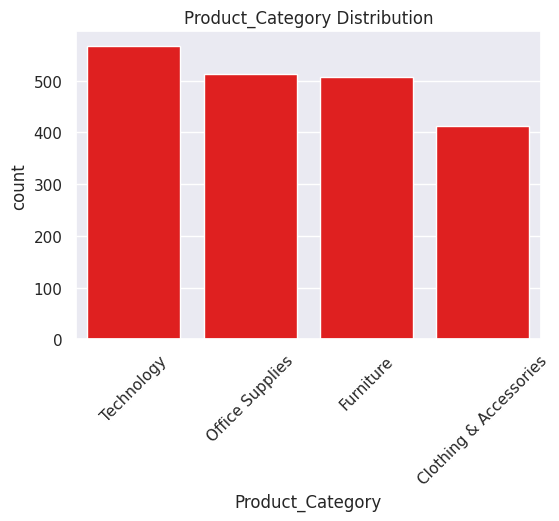

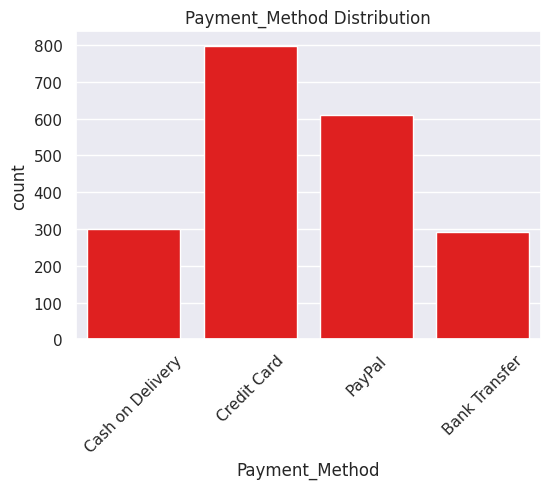

In [ ]:
cols = ['Customer_Segment', 'Region', 'Product_Category', 'Payment_Method']

for col in cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df,color="red")
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
    plt.show()

# **Revenue & Profit Analysis**

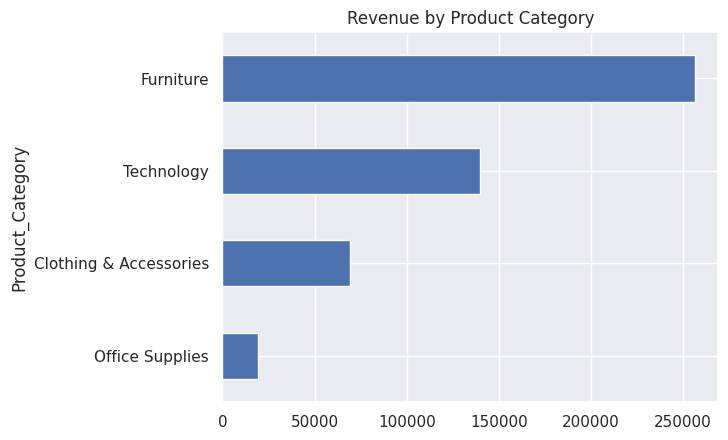

In [ ]:
# Revenue by Product Category
df.groupby('Product_Category')['Total_Sales'].sum().sort_values().plot(kind='barh')
plt.title("Revenue by Product Category")
plt.show()

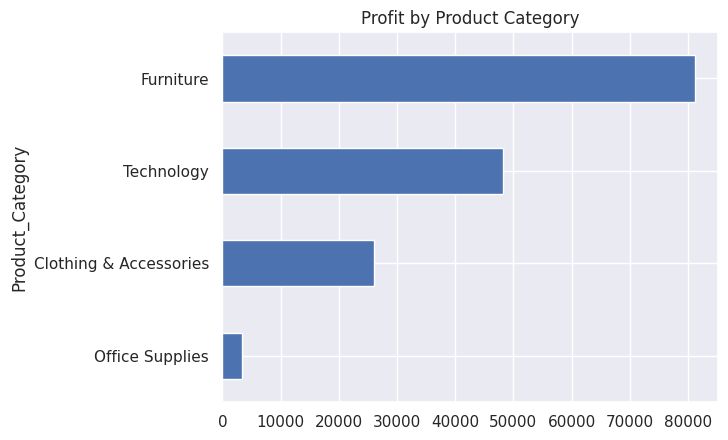

In [ ]:
# Profit by Category
df.groupby('Product_Category')['Profit'].sum().sort_values().plot(kind='barh')
plt.title("Profit by Product Category")
plt.show()

# **Regional Performance**

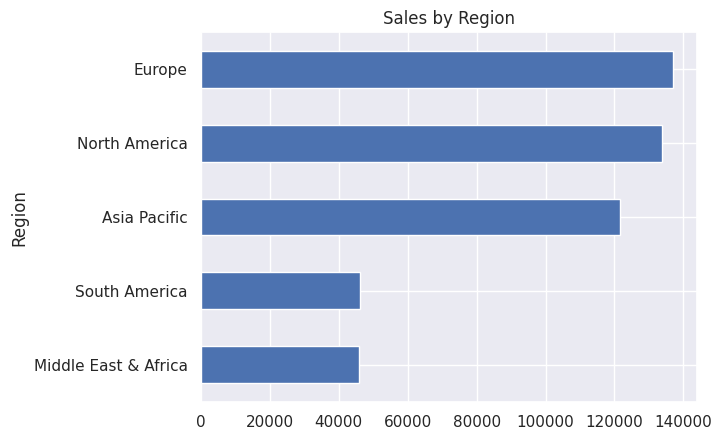

In [ ]:
#Sales by Region
df.groupby('Region')['Total_Sales'].sum().sort_values().plot(kind='barh')
plt.title("Sales by Region")
plt.show()

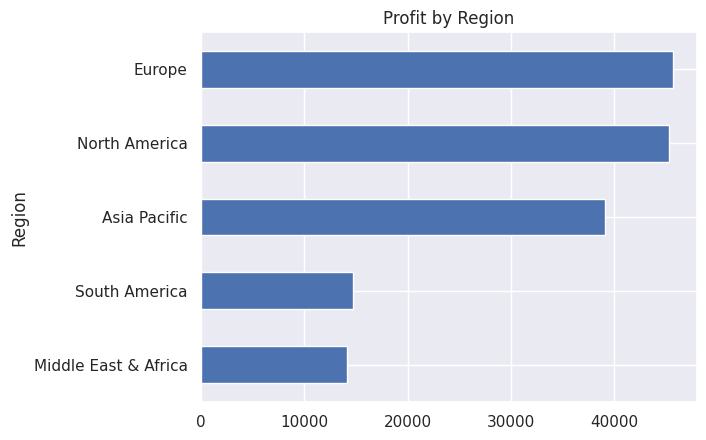

In [ ]:
#Profit by Region
df.groupby('Region')['Profit'].sum().sort_values().plot(kind='barh')
plt.title("Profit by Region")
plt.show()

Analysis of product category performance reveals that Furniture is the dominant category, contributing the highest share of both revenue and profit. Technology follows as a strong secondary contributor, while Clothing & Accessories show moderate performance. Office Supplies significantly underperform across both revenue and profit metrics.

The alignment between revenue and profit across categories suggests consistent margins; however, the heavy reliance on Furniture indicates potential business risk. Opportunities exist to improve underperforming categories through targeted pricing, promotions, or product strategy adjustments.

# **Time Series Analysis**

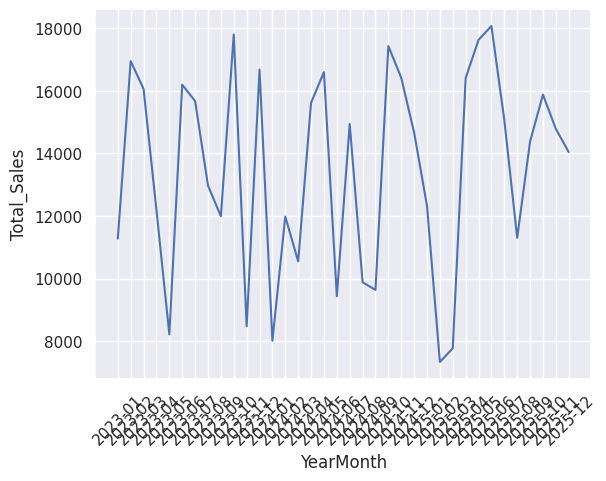

In [ ]:
#Sales by Month

# 1. Check year distribution
df['Year'].value_counts()

# 2. Create proper timeline
df['YearMonth'] = df['Order_Date'].dt.to_period('M').astype(str)

# 3. Group and sort
monthly_sales = df.groupby('YearMonth')['Total_Sales'].sum().reset_index()
monthly_sales = monthly_sales.sort_values('YearMonth')

# 4. Plot
sns.lineplot(data=monthly_sales, x='YearMonth', y='Total_Sales')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['Year'].value_counts()

,count
Year,
2025,681
2023,670
2024,649


# **Products and Customers**


In [ ]:
# Most bought product
df.groupby('Product_Name')['Total_Sales'].sum().sort_values(ascending=False).head(10)

,Total_Sales
Product_Name,
Standing Desk Converter,46614.22
Ergonomic Office Chair,45405.15
Corner L-Shaped Desk,41070.48
Mesh Back Task Chair,38179.77
Wireless Bluetooth Headphones,28258.70
Mechanical Gaming Keyboard,24072.42
Filing Cabinet 3-Drawer,23108.01
Folding Table Portable,18663.13
Portable External SSD 1TB,18065.30


In [ ]:
# Top Customer
df.groupby('Customer_Name')['Total_Sales'].sum().sort_values(ascending=False).head(10)

,Total_Sales
Customer_Name,
Priya Jackson,3836.46
Hanna Jones,3813.98
Sarah Chen,3184.56
Li Laurent,3007.62
Nadia Wang,2958.97
Priya Oliveira,2901.11
Felix Thompson,2835.36
Linda Weber,2762.40
Karen Sato,2738.18


# **Shipping Cost Impact**

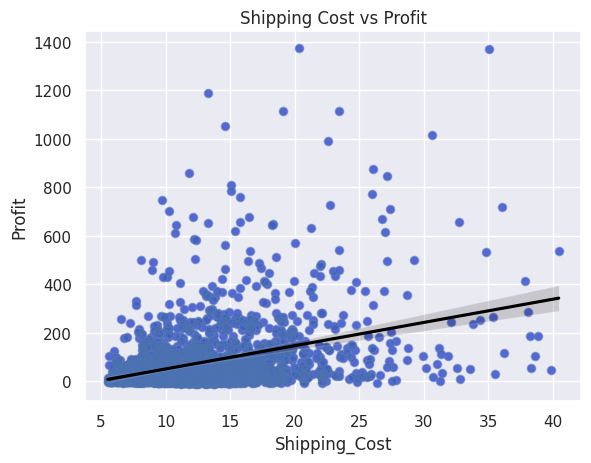

In [ ]:
sns.scatterplot(data=df, x='Shipping_Cost', y='Profit', color='blue', alpha=0.6)
sns.regplot(data=df, x='Shipping_Cost', y='Profit', scatter_kws={'alpha':0.5}, line_kws={'color':'black'})
plt.title("Shipping Cost vs Profit")
plt.show()

The scatter plot shows a weak relationship between shipping cost and profit. Most transactions occur at lower shipping costs with relatively low profits, while high-profit values are scattered across different shipping cost levels. This suggests that shipping cost is not a strong predictor of profit

# **Discount vs Profit**

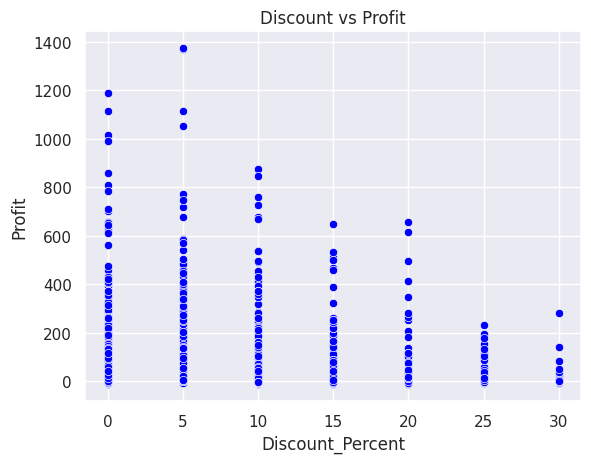

In [ ]:
sns.scatterplot(data=df, x='Discount_Percent', y='Profit', color = "blue")
plt.title("Discount vs Profit")
plt.show()

The plot indicates a negative relationship between discount percentage and profit. Higher discounts are generally associated with lower profits, while higher profits are more common at lower discount levels. This suggests that aggressive discounting may reduce profitability

# **Correlation Analysis**

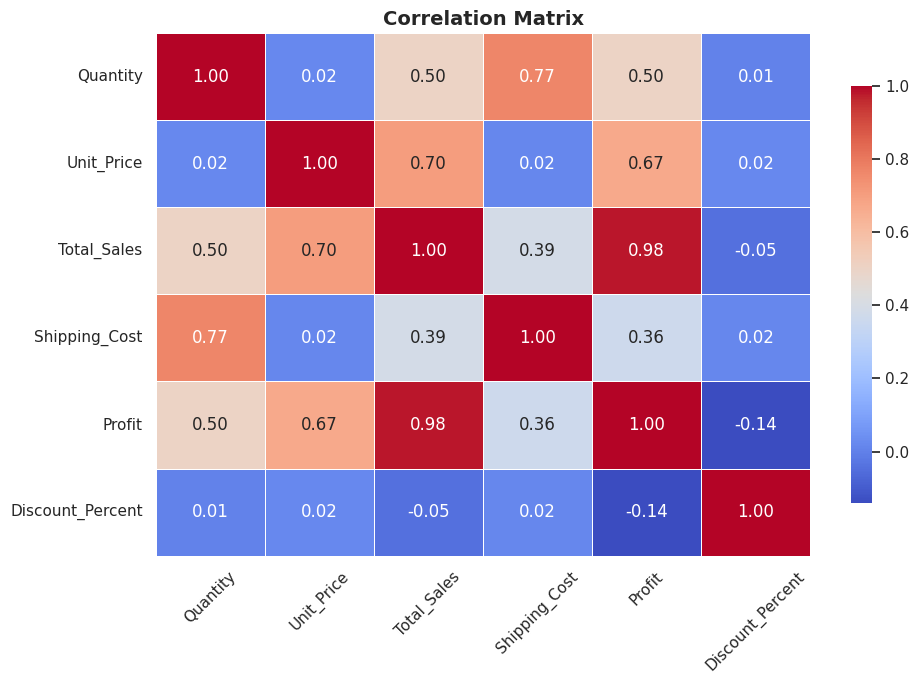

In [ ]:
corr = df[['Quantity','Unit_Price','Total_Sales',
           'Shipping_Cost','Profit','Discount_Percent']].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

The correlation analysis shows that Total Sales and Profit are highly correlated (0.98), indicating that revenue is the primary driver of profitability.

Unit Price also shows a strong relationship with both Total Sales (0.7) and Profit (0.67), suggesting that higher-priced products contribute significantly to business performance.

Shipping Cost is strongly correlated with Quantity (0.77), which is expected as larger orders incur higher logistics costs.

Interestingly, Discount Percentage has little to no correlation with Total Sales (-0.046) and a slight negative relationship with Profit (-0.14), implying that discounts may not be an effective strategy for increasing revenue and could slightly reduce profitability.


# Export Data to Tableau

In [ ]:
df.to_csv('cleaned_data.csv', index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df.to_csv('/content/drive/MyDrive/cleaned_data.csv', index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
